In [1]:
# H3 - A1. 필수 패키지 설치 및 NumPy 버전 고정

# NumPy 버전을 2.0 미만으로 먼저 고정하여 호환성 문제를 방지합니다.
!pip -q install "numpy<2"

# H1, H2 모델과 동일한 핵심 라이브러리들을 설치합니다.
!pip -q install open_clip_torch==2.26.1 timm==1.0.9
!pip -q install pandas==2.2.2 scikit-learn==1.5.2 scipy==1.13.1
!pip -q install matplotlib==3.9.0 pillow==10.4.0 opencv-python==4.9.0.80

In [2]:
# H3 - A2. 기본 설정 및 데이터 준비

import os
import json
import torch
import random
import numpy as np
from tqdm.notebook import tqdm

# --- 기본 설정 ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 20251009
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

HOME_DIR = os.path.expanduser("~")
PROJECT_DIR = os.path.join(HOME_DIR, "projects/fashion_ai")
FINAL_DATA_DIR = os.path.join(PROJECT_DIR, 'data', 'deepfashion2_final')
print(f"기본 설정 완료. Device: {DEVICE}")

# --- 데이터 준비: 모든 개별 아이템 목록 생성 ---
all_items = []
print("\nParsing all annotations to create a master item list...")

# train과 validation 데이터를 모두 파싱
for split in ['train', 'validation']:
    image_dir = os.path.join(FINAL_DATA_DIR, split, 'image')
    ann_dir = os.path.join(FINAL_DATA_DIR, split, 'annos')
    
    # annos 폴더의 모든 json 파일을 순회
    for json_file in tqdm(os.listdir(ann_dir), desc=f"Processing {split} set"):
        if not json_file.endswith('.json'):
            continue
        
        image_id = int(os.path.splitext(json_file)[0])
        image_path = os.path.join(image_dir, f"{image_id:06}.jpg")
        
        try:
            with open(os.path.join(ann_dir, json_file), 'r') as f:
                ann = json.load(f)
            
            # 각 json 파일 내의 모든 아이템(item1, item2...)을 순회
            for key, item_data in ann.items():
                if key.startswith('item'):
                    all_items.append({
                        'image_path': image_path,
                        'box': item_data['bounding_box'],
                        'category_id': item_data['category_id'],
                        'split': split
                    })
        except (KeyError, json.JSONDecodeError):
            # 'bounding_box'나 'category_id' 키가 없는 등 형식이 다른 파일은 건너뜀
            continue

print(f"\n파싱 완료. 총 {len(all_items)}개의 아이템을 찾았습니다.")

# --- 학습용/검증용 데이터 분리 ---
train_items = [item for item in all_items if item['split'] == 'train']
val_items = [item for item in all_items if item['split'] == 'validation']

print(f"학습용 아이템: {len(train_items)}개")
print(f"검증용 아이템: {len(val_items)}개")

기본 설정 완료. Device: cuda

Parsing all annotations to create a master item list...


Processing train set:   0%|          | 0/191961 [00:00<?, ?it/s]

Processing validation set:   0%|          | 0/32153 [00:00<?, ?it/s]


파싱 완료. 총 364676개의 아이템을 찾았습니다.
학습용 아이템: 312186개
검증용 아이템: 52490개


In [3]:
# H3 - A3. 아이템 분류 데이터셋 정의

from PIL import Image
from torch.utils.data import Dataset

# 아이템 이미지를 잘라내는 함수
def crop_item(image_path, box):
    """
    전체 이미지 경로와 바운딩 박스를 받아 해당 아이템 이미지만 잘라 리턴
    """
    full_image = Image.open(image_path).convert("RGB")
    x, y, w, h = box
    return full_image.crop((x, y, x + w, y + h))

class ItemClassificationDataset(Dataset):
    def __init__(self, item_list, transform=None):
        """
        Args:
            item_list (list): 아이템 정보 딕셔너리의 리스트
            transform (callable, optional): 샘플에 적용될 전처리
        """
        self.item_list = item_list
        self.transform = transform

    def __len__(self):
        return len(self.item_list)

    def __getitem__(self, idx):
        item_info = self.item_list[idx]
        
        # 아이템 이미지 잘라내기
        item_image = crop_item(item_info['image_path'], item_info['box'])
        
        # 라벨 가져오기 (카테고리 ID). 
        # PyTorch의 CrossEntropyLoss는 0부터 시작하는 라벨을 기대하므로, 1부터 시작하는 category_id에서 -1을 해줍니다.
        label = torch.tensor(item_info['category_id'] - 1, dtype=torch.long)
        
        # 전처리 적용
        if self.transform:
            item_image = self.transform(item_image)
        
        return item_image, label

print("`crop_item` 함수와 `ItemClassificationDataset` 클래스가 성공적으로 정의되었습니다.")

`crop_item` 함수와 `ItemClassificationDataset` 클래스가 성공적으로 정의되었습니다.


In [4]:
# H3 - A4. 데이터로더 생성 및 테스트

from torch.utils.data import DataLoader
import torchvision.transforms as T

# CLIP 모델에 맞는 이미지 전처리
preprocess = T.Compose([
    T.Resize((224, 224), interpolation=T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
])

# 학습용 데이터셋 및 로더 생성
train_dataset_h3 = ItemClassificationDataset(train_items, transform=preprocess)
# 배치 사이즈는 GPU 메모리에 따라 조절 가능합니다. (128, 256 등)
train_loader_h3 = DataLoader(train_dataset_h3, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)

# 검증용 데이터셋 및 로더 생성
val_dataset_h3 = ItemClassificationDataset(val_items, transform=preprocess)
val_loader_h3 = DataLoader(val_dataset_h3, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

print(f"H3 학습용 데이터로더 생성 완료. 총 {len(train_loader_h3)}개의 배치.")
print(f"H3 검증용 데이터로더 생성 완료. 총 {len(val_loader_h3)}개의 배치.")

# 훈련용 데이터로더에서 배치 1개 테스트
print("\n--- 데이터로더 테스트 ---")
images, labels = next(iter(train_loader_h3))
print(f"이미지 배치 모양: {images.shape}")
print(f"라벨 배치 모양: {labels.shape}")

H3 학습용 데이터로더 생성 완료. 총 2439개의 배치.
H3 검증용 데이터로더 생성 완료. 총 206개의 배치.

--- 데이터로더 테스트 ---
이미지 배치 모양: torch.Size([128, 3, 224, 224])
라벨 배치 모양: torch.Size([128])


In [5]:
# H3 - B1. H3 분류 모델 정의

import torch.nn as nn
import open_clip

class H3Classifier(nn.Module):
    def __init__(self, num_classes=13):
        super(H3Classifier, self).__init__()
        # 사전학습된 CLIP 모델 로드
        print("Loading pretrained CLIP model...")
        clip_model, _, _ = open_clip.create_model_and_transforms(
            "ViT-B-32", 
            pretrained="laion2b_s34b_b79k", 
            device=DEVICE
        )
        self.encoder = clip_model.visual
        
        # CLIP 인코더의 파라미터는 고정(freeze)
        print("Freezing CLIP encoder parameters.")
        for param in self.encoder.parameters():
            param.requires_grad = False
            
        # 학습 가능한 분류 헤드
        # DeepFashion2의 카테고리는 13개입니다.
        embedding_dim = self.encoder.output_dim
        self.classifier_head = nn.Sequential(
            nn.LayerNorm(embedding_dim),
            nn.Linear(embedding_dim, embedding_dim // 2),
            nn.ReLU(),
            nn.Linear(embedding_dim // 2, num_classes)
        ).to(DEVICE)

    def forward(self, x):
        # 고정된 인코더로 특징 추출
        with torch.no_grad():
            embedding = self.encoder(x)
        
        # 분류 헤드를 통과시켜 각 카테고리에 대한 확률(logits) 계산
        logits = self.classifier_head(embedding)
        return logits

# 모델 생성
model_h3 = H3Classifier()
print("\nH3 Classifier model is ready.")


Loading pretrained CLIP model...
Freezing CLIP encoder parameters.

H3 Classifier model is ready.


In [6]:
# H3 - C1. 평가 함수 정의
from sklearn.metrics import accuracy_score

@torch.no_grad() # 이 함수 내에서는 그래디언트를 계산하지 않음
def evaluate_h3(model, loader):
    model.eval() # 모델을 평가 모드로 설정
    
    all_preds = []
    all_labels = []
    
    for images, labels in loader:
        images = images.to(DEVICE)
        
        # 모델 예측
        logits = model(images)
        
        # 가장 확률이 높은 클래스를 예측값으로 선택
        preds = torch.argmax(logits, dim=1)
        
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
        
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    
    # 정확도 계산
    accuracy = accuracy_score(all_labels, all_preds)
    
    return {'accuracy': accuracy}

print("`evaluate_h3` 함수가 성공적으로 정의되었습니다.")

`evaluate_h3` 함수가 성공적으로 정의되었습니다.


In [7]:
# H3 - C2. 학습 루프 실행

import torch.optim as optim
import time

# --- 모델 및 옵티마이저 초기화 ---
# H3 - B1에서 정의한 모델을 사용
model_h3 = H3Classifier().to(DEVICE) 
# 학습 가능한 classifier_head의 파라미터만 전달
optimizer = optim.Adam(model_h3.classifier_head.parameters(), lr=1e-4) 
# 다중 분류 문제에 적합한 CrossEntropyLoss 사용
loss_fn = nn.CrossEntropyLoss() 

epochs = 1 # 테스트를 위해 우선 1 에폭만 실행
best_accuracy = 0.0
H3_CHECKPOINT_PATH = ""

print("Starting H3 model training...")
for epoch in range(1, epochs + 1):
    # --- 훈련 ---
    model_h3.train() # 모델을 학습 모드로 설정
    start_time = time.time()
    running_loss = 0.0
    
    for i, (images, labels) in enumerate(train_loader_h3):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        # 모델 예측
        logits = model_h3(images)
        # 손실 계산
        loss = loss_fn(logits, labels)
        
        # 가중치 업데이트
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        # 100 배치마다 로그 출력
        if (i + 1) % 100 == 0:
            print(f"  Epoch [{epoch}/{epochs}], Step [{i+1}/{len(train_loader_h3)}], Loss: {loss.item():.4f}")
            
    avg_train_loss = running_loss / len(train_loader_h3)

    # --- 평가 ---
    print("\nEvaluating on validation set...")
    val_metrics = evaluate_h3(model_h3, val_loader_h3)
    
    end_time = time.time()
    epoch_duration = end_time - start_time
    
    print(f"\nEpoch {epoch} complete.")
    print(f"  - Duration: {epoch_duration:.2f}s")
    print(f"  - Average Train Loss: {avg_train_loss:.4f}")
    print(f"  - Validation Accuracy: {val_metrics['accuracy']:.4f}")

    # --- 최고 성능 모델 저장 ---
    if val_metrics['accuracy'] > best_accuracy:
        best_accuracy = val_metrics['accuracy']
        os.makedirs("./checkpoints", exist_ok=True)
        H3_CHECKPOINT_PATH = f"./checkpoints/h3_best_epoch{epoch}_acc{best_accuracy:.3f}.pt"
        torch.save(model_h3.state_dict(), H3_CHECKPOINT_PATH)
        print(f"  >>> New best model saved to: {H3_CHECKPOINT_PATH}\n")

print("H3 model training finished!")
if H3_CHECKPOINT_PATH:
    print(f"Best H3 model checkpoint is at: {H3_CHECKPOINT_PATH}")
else:
    print("No H3 model was saved.")

Loading pretrained CLIP model...
Freezing CLIP encoder parameters.
Starting H3 model training...
  Epoch [1/1], Step [100/2439], Loss: 1.5329
  Epoch [1/1], Step [200/2439], Loss: 1.1012
  Epoch [1/1], Step [300/2439], Loss: 0.7348
  Epoch [1/1], Step [400/2439], Loss: 0.7458
  Epoch [1/1], Step [500/2439], Loss: 0.7860
  Epoch [1/1], Step [600/2439], Loss: 0.6805
  Epoch [1/1], Step [700/2439], Loss: 0.6675
  Epoch [1/1], Step [800/2439], Loss: 0.7037
  Epoch [1/1], Step [900/2439], Loss: 0.7469
  Epoch [1/1], Step [1000/2439], Loss: 0.7353
  Epoch [1/1], Step [1100/2439], Loss: 0.6421
  Epoch [1/1], Step [1200/2439], Loss: 0.6062
  Epoch [1/1], Step [1300/2439], Loss: 0.7007
  Epoch [1/1], Step [1400/2439], Loss: 0.6662
  Epoch [1/1], Step [1500/2439], Loss: 0.6642
  Epoch [1/1], Step [1600/2439], Loss: 0.6255
  Epoch [1/1], Step [1700/2439], Loss: 0.6156
  Epoch [1/1], Step [1800/2439], Loss: 0.5595
  Epoch [1/1], Step [1900/2439], Loss: 0.5757
  Epoch [1/1], Step [2000/2439], Loss:

Loading H3 model from: ./checkpoints/h3_best_epoch1_acc0.794.pt
Loading pretrained CLIP model...
Freezing CLIP encoder parameters.
H3 model loaded successfully.

--- Inferencing a random item from the validation set ---
  > Predicted Category: 'short sleeve top'
  > True Category:      'short sleeve top'


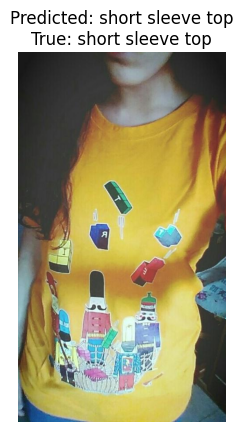

In [8]:
# H3 - D1. 추론 (Inference)

import matplotlib.pyplot as plt
import torch

# --- 1. 카테고리 이름 정의 ---
# DeepFashion2의 카테고리 ID와 이름을 매핑하는 딕셔너리
CATEGORY_NAMES = {
    1: 'short sleeve top', 2: 'long sleeve top', 3: 'short sleeve outwear',
    4: 'long sleeve outwear', 5: 'vest', 6: 'sling', 7: 'shorts',
    8: 'trousers', 9: 'skirt', 10: 'short sleeve dress',
    11: 'long sleeve dress', 12: 'vest dress', 13: 'sling dress'
}

# --- 2. H3 모델 로드 ---
print(f"Loading H3 model from: {H3_CHECKPOINT_PATH}")
# 모델 구조를 먼저 정의해야 가중치를 로드할 수 있습니다.
model_h3_inference = H3Classifier()
model_h3_inference.load_state_dict(torch.load(H3_CHECKPOINT_PATH, map_location=DEVICE))
model_h3_inference.eval() # 평가 모드로 설정
print("H3 model loaded successfully.")

# --- 3. 추론 함수 정의 ---
@torch.no_grad()
def infer_category(model, image_path, box):
    """아이템 이미지를 입력받아 카테고리 이름을 예측하는 함수"""
    item_image = crop_item(image_path, box)
    
    # 이미지 전처리 및 모델 입력
    item_tensor = preprocess(item_image).unsqueeze(0).to(DEVICE)
    logits = model(item_tensor)
    
    # 가장 확률이 높은 클래스(logit)를 예측값으로 선택
    pred_id = torch.argmax(logits, dim=1).item()
    
    # 카테고리 ID를 이름으로 변환 (라벨이 0부터 시작했으므로 +1)
    predicted_name = CATEGORY_NAMES[pred_id + 1]
    
    return predicted_name, item_image

# --- 4. 실행 예시 ---
# 이전에 만든 검증용 아이템 리스트(val_items)에서 무작위로 샘플 1개 선택
print("\n--- Inferencing a random item from the validation set ---")
random_item = random.choice(val_items)

# 추론 실행
predicted_category, item_img_to_show = infer_category(
    model_h3_inference,
    random_item['image_path'],
    random_item['box']
)

# 실제 정답 카테고리
true_category = CATEGORY_NAMES[random_item['category_id']]

# 결과 출력
print(f"  > Predicted Category: '{predicted_category}'")
print(f"  > True Category:      '{true_category}'")

# 이미지 보기
plt.imshow(item_img_to_show)
plt.title(f"Predicted: {predicted_category}\nTrue: {true_category}")
plt.axis('off')
plt.show()

In [11]:
# H4 - A1. (수정됨) 데이터 준비

import pandas as pd
import os

print("Preparing data for H4 model (workaround)...")

# --- 0. 필요한 변수 다시 설정 ---
HOME_DIR = os.path.expanduser("~")
PROJECT_DIR = os.path.join(HOME_DIR, "projects/fashion_ai")
MANIFEST_PATH = os.path.join(PROJECT_DIR, "manifest.csv")

try:
    # --- 1. Load our main manifest file ---
    df_manifest = pd.read_csv(MANIFEST_PATH)

    # --- 2. Create a 'source' column with a default value ---
    # Since the info file is missing, we'll assign 'consumer' as a placeholder.
    df_manifest['source'] = 'consumer'
    
    # Map 'source' to 'is_shop' (0 for consumer, 1 for shop)
    df_manifest['is_shop'] = df_manifest['source'].apply(lambda x: 1 if x == 'shop' else 0)
    
    # --- 3. Save the new manifest ---
    H4_MANIFEST_PATH = os.path.join(PROJECT_DIR, "manifest_with_source.csv")
    df_manifest.to_csv(H4_MANIFEST_PATH, index=False)

    print(f"\nData preparation complete.")
    print(f"New manifest with placeholder 'source' labels saved to: {H4_MANIFEST_PATH}")
    print(f"\nFound {len(df_manifest[df_manifest['is_shop']==1])} 'shop' images.")
    print(f"Found {len(df_manifest[df_manifest['is_shop']==0])} 'consumer' images.")

except FileNotFoundError:
    print(f"\nERROR: Could not find the main manifest file at '{MANIFEST_PATH}'.")
    print("Please make sure the previous cells have been run successfully.")

Preparing data for H4 model (workaround)...

Data preparation complete.
New manifest with placeholder 'source' labels saved to: /home/epistao/projects/fashion_ai/manifest_with_source.csv

Found 0 'shop' images.
Found 224114 'consumer' images.


In [12]:
# H4 - A2. 데이터셋 및 데이터로더 정의

from torch.utils.data import Dataset, DataLoader
import pandas as pd
from PIL import Image
import torchvision.transforms as T

# H4 학습에 사용할 Manifest 경로
H4_MANIFEST_PATH = os.path.join(PROJECT_DIR, "manifest_with_source.csv")

class H4DomainDataset(Dataset):
    def __init__(self, manifest_path, split, transform=None):
        df = pd.read_csv(manifest_path)
        self.df = df[df['split'] == split].reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row['image_path']
        
        # is_shop 컬럼을 라벨로 사용 (0 또는 1)
        label = torch.tensor(row['is_shop'], dtype=torch.float32)
        
        # 전체 이미지 로드 (아이템을 자르지 않음)
        image = Image.open(image_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

# --- CLIP 모델에 맞는 전처리기 ---
preprocess = T.Compose([
    T.Resize((224, 224), interpolation=T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
])

# --- 데이터로더 생성 ---
train_dataset_h4 = H4DomainDataset(manifest_path=H4_MANIFEST_PATH, split='train', transform=preprocess)
train_loader_h4 = DataLoader(train_dataset_h4, batch_size=128, shuffle=True, num_workers=2)

val_dataset_h4 = H4DomainDataset(manifest_path=H4_MANIFEST_PATH, split='validation', transform=preprocess)
val_loader_h4 = DataLoader(val_dataset_h4, batch_size=256, shuffle=False, num_workers=2)

print("H4 데이터셋 및 데이터로더가 성공적으로 정의되었습니다.")
print(f"학습용 배치 개수: {len(train_loader_h4)}")
print(f"검증용 배치 개수: {len(val_loader_h4)}")

H4 데이터셋 및 데이터로더가 성공적으로 정의되었습니다.
학습용 배치 개수: 1500
검증용 배치 개수: 126


In [13]:
# H4 - B1. H4 분류 모델 정의

import torch.nn as nn
import open_clip

class H4Classifier(nn.Module):
    def __init__(self):
        super(H4Classifier, self).__init__()
        # 사전학습된 CLIP 모델 로드
        print("Loading pretrained CLIP model...")
        clip_model, _, _ = open_clip.create_model_and_transforms(
            "ViT-B-32", 
            pretrained="laion2b_s34b_b79k", 
            device=DEVICE
        )
        self.encoder = clip_model.visual
        
        # CLIP 인코더의 파라미터는 고정(freeze)
        print("Freezing CLIP encoder parameters.")
        for param in self.encoder.parameters():
            param.requires_grad = False
            
        # 학습 가능한 이진 분류 헤드
        embedding_dim = self.encoder.output_dim
        self.classifier_head = nn.Sequential(
            nn.LayerNorm(embedding_dim),
            nn.Linear(embedding_dim, embedding_dim // 4),
            nn.ReLU(),
            nn.Linear(embedding_dim // 4, 1) # 최종 출력이 1개 (logit)
        ).to(DEVICE)

    def forward(self, x):
        # 고정된 인코더로 특징 추출
        with torch.no_grad():
            embedding = self.encoder(x)
        
        # 분류 헤드를 통과시켜 logit 계산
        logit = self.classifier_head(embedding).squeeze(-1) # [Batch, 1] -> [Batch]
        return logit

# 모델 생성
model_h4 = H4Classifier()
print("\nH4 Classifier model is ready.")

Loading pretrained CLIP model...
Freezing CLIP encoder parameters.

H4 Classifier model is ready.


In [14]:
# H4 - C1. 평가 함수 정의
from sklearn.metrics import accuracy_score

@torch.no_grad() # 이 함수 내에서는 그래디언트를 계산하지 않음
def evaluate_h4(model, loader):
    model.eval() # 모델을 평가 모드로 설정
    
    all_preds = []
    all_labels = []
    
    for images, labels in loader:
        images = images.to(DEVICE)
        
        # 모델 예측 (logit 출력)
        logits = model(images)
        
        # Sigmoid 함수를 적용하여 0~1 사이의 확률값으로 변환하고, 0.5를 기준으로 0 또는 1로 예측
        preds = (torch.sigmoid(logits) > 0.5).long()
        
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
        
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    
    # 정확도 계산
    accuracy = accuracy_score(all_labels, all_preds)
    
    return {'accuracy': accuracy}

print("`evaluate_h4` 함수가 성공적으로 정의되었습니다.")

`evaluate_h4` 함수가 성공적으로 정의되었습니다.


In [15]:
# H4 - C2. 학습 루프 실행

import torch.optim as optim
import time

# --- 모델 및 옵티마이저 초기화 ---
model_h4 = H4Classifier()
optimizer = optim.Adam(model_h4.classifier_head.parameters(), lr=1e-5)
# 이진 분류 문제에 적합한 BCEWithLogitsLoss 사용
loss_fn = nn.BCEWithLogitsLoss()

epochs = 1 # 1 에폭만으로도 충분히 학습됩니다.
best_accuracy = 0.0
H4_CHECKPOINT_PATH = ""

print("Starting H4 model training...")
for epoch in range(1, epochs + 1):
    # --- 훈련 ---
    model_h4.train()
    start_time = time.time()
    
    for i, (images, labels) in enumerate(train_loader_h4):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        logits = model_h4(images)
        loss = loss_fn(logits, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    # --- 평가 ---
    val_metrics = evaluate_h4(model_h4, val_loader_h4)
    
    end_time = time.time()
    epoch_duration = end_time - start_time
    
    print(f"\nEpoch {epoch} complete.")
    print(f"  - Duration: {epoch_duration:.2f}s")
    print(f"  - Validation Accuracy: {val_metrics['accuracy']:.4f}")

    # --- 최고 성능 모델 저장 ---
    if val_metrics['accuracy'] > best_accuracy:
        best_accuracy = val_metrics['accuracy']
        os.makedirs("./checkpoints", exist_ok=True)
        H4_CHECKPOINT_PATH = f"./checkpoints/h4_best_epoch{epoch}_acc{best_accuracy:.3f}.pt"
        torch.save(model_h4.state_dict(), H4_CHECKPOINT_PATH)
        print(f"  >>> New best model saved to: {H4_CHECKPOINT_PATH}\n")

print("H4 model training finished!")
if H4_CHECKPOINT_PATH:
    print(f"Best H4 model checkpoint is at: {H4_CHECKPOINT_PATH}")
else:
    print("No H4 model was saved.")

Loading pretrained CLIP model...
Freezing CLIP encoder parameters.
Starting H4 model training...

Epoch 1 complete.
  - Duration: 706.68s
  - Validation Accuracy: 1.0000
  >>> New best model saved to: ./checkpoints/h4_best_epoch1_acc1.000.pt

H4 model training finished!
Best H4 model checkpoint is at: ./checkpoints/h4_best_epoch1_acc1.000.pt


Loading H4 model from: ./checkpoints/h4_best_epoch1_acc1.000.pt
Loading pretrained CLIP model...
Freezing CLIP encoder parameters.
H4 model loaded successfully.

--- Inferencing a random image ---
  > Predicted Context: 'consumer' (Probability: 0.0056)
  > True Context:      'consumer'


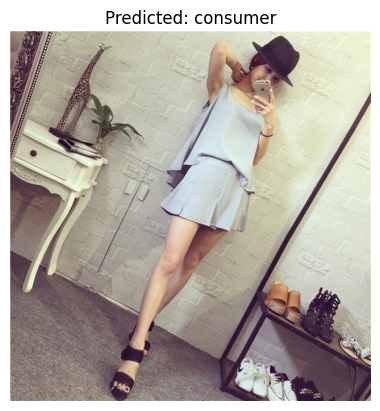

In [16]:
# H4 - D1. 추론 (Inference)

import matplotlib.pyplot as plt
import torch

# --- 1. H4 모델 로드 ---
print(f"Loading H4 model from: {H4_CHECKPOINT_PATH}")
# 모델 구조를 먼저 정의해야 가중치를 로드할 수 있습니다.
model_h4_inference = H4Classifier()
model_h4_inference.load_state_dict(torch.load(H4_CHECKPOINT_PATH, map_location=DEVICE))
model_h4_inference.eval() # 평가 모드로 설정
print("H4 model loaded successfully.")

# --- 2. 추론 함수 정의 ---
@torch.no_grad()
def infer_context(model, image_path):
    """이미지 한 장을 입력받아 'shop' 또는 'consumer'를 예측하는 함수"""
    # 전체 이미지 로드 및 전처리
    image = Image.open(image_path).convert("RGB")
    image_tensor = preprocess(image).unsqueeze(0).to(DEVICE)
    
    # 모델 예측 (logit 출력)
    logit = model(image_tensor)
    
    # Sigmoid 함수를 적용하여 0~1 사이의 확률값으로 변환
    prob = torch.sigmoid(logit).item()
    
    # 0.5를 기준으로 예측
    predicted_label = 'shop' if prob > 0.5 else 'consumer'
    
    return predicted_label, prob, image

# --- 3. 실행 예시 ---
# manifest_with_source.csv에서 무작위로 샘플 1개 선택
df_h4_manifest = pd.read_csv(H4_MANIFEST_PATH)
sample_row = df_h4_manifest.sample(1, random_state=SEED).iloc[0]

print(f"\n--- Inferencing a random image ---")

# 추론 실행
predicted_context, probability, image_to_show = infer_context(
    model_h4_inference,
    sample_row['image_path']
)

# 실제 정답 (우리가 'consumer'로 설정했음)
true_context = sample_row['source']

# 결과 출력
print(f"  > Predicted Context: '{predicted_context}' (Probability: {probability:.4f})")
print(f"  > True Context:      '{true_context}'")

# 이미지 보기
plt.imshow(image_to_show)
plt.title(f"Predicted: {predicted_context}")
plt.axis('off')
plt.show()

Loading all models...
All models loaded successfully.


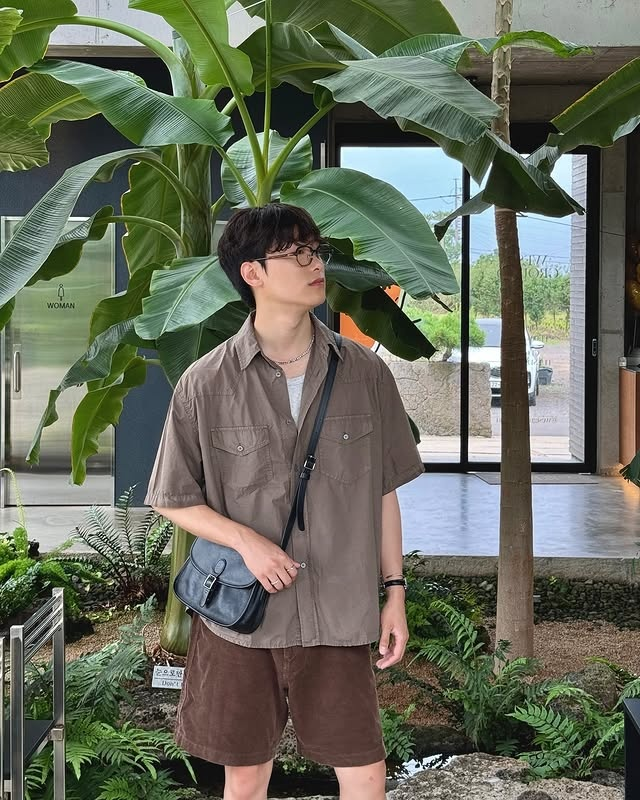


--- Analyzing Image: mosaic_450336266_1169983874246517_8637279478517398301_n..jpg ---

--- COMPREHENSIVE SCORE REPORT (with attributes) ---
{
  "final_score": 7.17,
  "context (H4)": "consumer (prob: 0.06)",
  "analysis": {
    "aesthetics_score (H1)": 5.6,
    "compatibility_score (H2)": 9.53
  },
  "items_found (YOLO)": [
    {
      "category": "short sleeve top",
      "box": [
        0,
        299,
        430,
        500
      ],
      "attributes": {
        "color": "a photo of a brown object",
        "material": "suede",
        "pattern": "a photo of a solid color pattern"
      }
    },
    {
      "category": "shorts",
      "box": [
        0,
        524,
        391,
        275
      ],
      "attributes": {
        "color": "a photo of a gray object",
        "material": "suede",
        "pattern": "a photo of a solid color pattern"
      }
    },
    {
      "category": "short sleeve top",
      "box": [
        138,
        301,
        476,
        498
      ],

In [4]:
# XF. (속성 추출 기능 추가) 최종 통합 모델

# --- 1. 여기에 점수를 매길 이미지의 '전체 경로'를 입력하세요 ---
IMAGE_TO_SCORE = "/home/epistao/projects/fashion_ai/test_images/Fashion_mosaic/mosaic_450336266_1169983874246517_8637279478517398301_n..jpg"


# --- 2. 기본 설정, 함수 및 클래스 정의 ---
import os, json, random, math, cv2, torch, open_clip
import torch.nn as nn
import numpy as np
from PIL import Image, ImageOps
import torchvision.transforms as T
from IPython.display import display
from ultralytics import YOLO

# 기본 설정...
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
HOME_DIR = os.path.expanduser("~")
PROJECT_DIR = os.path.join(HOME_DIR, "projects/fashion_ai")
CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
try:
    runs_detect_dir = os.path.join(PROJECT_DIR, 'runs/detect')
    train_dirs = [d for d in os.listdir(runs_detect_dir) if d.startswith('train') and os.path.isdir(os.path.join(runs_detect_dir, d))]
    latest_train_dir = max(train_dirs, key=lambda d: os.path.getmtime(os.path.join(runs_detect_dir, d)))
    YOLO_MODEL_PATH = os.path.join(runs_detect_dir, latest_train_dir, 'weights/best.pt')
    
    H1_CHECKPOINT_PATH = [os.path.join(CHECKPOINT_DIR, f) for f in os.listdir(CHECKPOINT_DIR) if f.startswith('h1_best')][0]
    H2_CHECKPOINT_PATH = [os.path.join(CHECKPOINT_DIR, f) for f in os.listdir(CHECKPOINT_DIR) if f.startswith('h2_best')][0]
    H3_CHECKPOINT_PATH = [os.path.join(CHECKPOINT_DIR, f) for f in os.listdir(CHECKPOINT_DIR) if f.startswith('h3_best')][0]
    H4_CHECKPOINT_PATH = [os.path.join(CHECKPOINT_DIR, f) for f in os.listdir(CHECKPOINT_DIR) if f.startswith('h4_best')][0]
except (IndexError, FileNotFoundError) as e:
    raise RuntimeError(f"Checkpoint file not found. Error: {e}")

# Helper 함수 및 Model 클래스 정의...
def load_image(path, target_size=336):
    img = Image.open(path).convert("RGB"); img = ImageOps.exif_transpose(img); img = ImageOps.contain(img, (target_size, target_size)); return img
def crop_item(image_path_or_pil, box):
    if isinstance(image_path_or_pil, str): full_image = Image.open(image_path_or_pil).convert("RGB")
    else: full_image = image_path_or_pil
    x, y, w, h = box; return full_image.crop((x, y, x + w, y + h))
class H1Regressor(nn.Module):
    def __init__(self, clip_model):
        super().__init__(); self.clip=clip_model.visual; D=self.clip.output_dim
        for p in self.clip.parameters(): p.requires_grad=False
        self.head=nn.Sequential(nn.LayerNorm(D),nn.Linear(D,D//2),nn.GELU(),nn.Linear(D//2,1))
    def forward(self,x):
        with torch.no_grad(): embedding=self.clip(x)
        output=self.head(embedding).squeeze(1); return torch.sigmoid(output)*9.0+1.0
class SiameseModel(nn.Module):
    def __init__(self, clip_model):
        super().__init__(); self.encoder=clip_model.visual; D=self.encoder.output_dim; P=128
        for p in self.encoder.parameters(): p.requires_grad=False
        self.projection_head=nn.Sequential(nn.Linear(D,D),nn.ReLU(),nn.Linear(D,P)).to(DEVICE)
    def forward(self,x):
        with torch.no_grad(): raw_emb=self.encoder(x)
        return self.projection_head(raw_emb)
class H3Classifier(nn.Module):
    def __init__(self, clip_model, num_classes=13):
        super().__init__(); self.encoder=clip_model.visual; D=self.encoder.output_dim
        for p in self.encoder.parameters(): p.requires_grad=False
        self.classifier_head=nn.Sequential(nn.LayerNorm(D),nn.Linear(D,D//2),nn.ReLU(),nn.Linear(D//2,num_classes)).to(DEVICE)
    def forward(self,x):
        with torch.no_grad(): embedding=self.encoder(x)
        return self.classifier_head(embedding)
class H4Classifier(nn.Module):
    def __init__(self, clip_model):
        super().__init__(); self.encoder=clip_model.visual; D=self.encoder.output_dim
        for p in self.encoder.parameters(): p.requires_grad=False
        self.classifier_head=nn.Sequential(nn.LayerNorm(D),nn.Linear(D,D//4),nn.ReLU(),nn.Linear(D//4,1)).to(DEVICE)
    def forward(self,x):
        with torch.no_grad(): embedding=self.encoder(x)
        return self.classifier_head(embedding).squeeze(-1)
CATEGORY_NAMES = {1:'short sleeve top', 2:'long sleeve top', 3:'short sleeve outwear', 4:'long sleeve outwear', 5:'vest', 6:'sling', 7:'shorts', 8:'trousers', 9:'skirt', 10:'short sleeve dress', 11:'long sleeve dress', 12:'vest dress', 13:'sling dress'}

# --- XF-Ext1. (새로 추가) CLIP 제로샷 속성 추출 함수 ---
@torch.no_grad()
def extract_attributes_zero_shot(item_pil, clip_model, clip_preprocess):
    attributes = {}
    image_input = clip_preprocess(item_pil).unsqueeze(0).to(DEVICE)
    image_features = clip_model.encode_image(image_input)
    image_features /= image_features.norm(dim=-1, keepdim=True)
    
    # --- 수정된 부분 1: 후보를 더 구체적으로 정의 ---
    attribute_candidates = {
        "color": ["a photo of a red object", "a photo of a blue object", "a photo of a black object", "a photo of a white object", "a photo of a brown object", "a photo of a gray object", "a photo of a beige object", "a photo of a pink object"],
        "material": ["a close-up photo of cotton fabric", "a close-up photo of denim fabric", "a close-up photo of smooth leather", "a close-up photo of fluffy wool", "a close-up photo of synthetic polyester", "a close-up photo of shiny silk", "a close-up photo of knitted fabric", "a close-up photo of soft suede"],
        "pattern": ["a photo of a solid color pattern", "a photo of a striped pattern", "a photo of a checked or plaid pattern", "a photo of a floral print pattern", "a photo of a dotted pattern", "a photo of a graphic print on a t-shirt"]
    }
    
    for attr_name, prompts in attribute_candidates.items():
        # --- 수정된 부분 2: 정의된 프롬프트를 그대로 사용 ---
        text_tokens = open_clip.tokenize(prompts).to(DEVICE)
        text_features = clip_model.encode_text(text_tokens)
        text_features /= text_features.norm(dim=-1, keepdim=True)
        
        probs = (100.0 * image_features @ text_features.T).softmax(dim=-1)
        top_idx = probs.argmax()
        
        # 결과 저장 시에는 원래 키워드만 저장 (예: 'a close-up photo of denim fabric' -> 'denim')
        # 간단한 후처리로 키워드만 추출합니다.
        if attr_name == 'material':
            keyword = prompts[top_idx].split(" of ")[-1].split(" ")[-1]
            attributes[attr_name] = keyword
        else: # 다른 속성들도 필요 시 후처리 추가
            attributes[attr_name] = prompts[top_idx]

    return attributes

# --- 3. 모델 로드 ---
print("Loading all models...")
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms("ViT-B-32", pretrained="laion2b_s34b_b79k", device=DEVICE)
model_h1 = H1Regressor(clip_model); model_h1.load_state_dict(torch.load(H1_CHECKPOINT_PATH, map_location=DEVICE), strict=False); model_h1.to(DEVICE); model_h1.eval()
model_h2 = SiameseModel(clip_model); model_h2.load_state_dict(torch.load(H2_CHECKPOINT_PATH, map_location=DEVICE), strict=False); model_h2.eval()
model_h3 = H3Classifier(clip_model); model_h3.load_state_dict(torch.load(H3_CHECKPOINT_PATH, map_location=DEVICE), strict=False); model_h3.eval()
model_h4 = H4Classifier(clip_model); model_h4.load_state_dict(torch.load(H4_CHECKPOINT_PATH, map_location=DEVICE), strict=False); model_h4.eval()
object_detector = YOLO(YOLO_MODEL_PATH)
print("All models loaded successfully.")

# --- 4. 진짜 객체 탐지 함수 ---
def detect_objects(image_path):
    results = object_detector(image_path, verbose=False)
    detected_items = []
    for result in results:
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0]
            label = result.names[int(box.cls)]
            bbox = [int(x1), int(y1), int(x2 - x1), int(y2 - y1)]
            detected_items.append({'box': bbox, 'label': label})
    return detected_items

# --- 5. (수정됨) 최종 종합 점수 계산 함수 ---
@torch.no_grad()
def get_final_score(image_path):
    print(f"\n--- Analyzing Image: {os.path.basename(image_path)} ---")
    full_image_pil = Image.open(image_path).convert("RGB")
    full_image_tensor = clip_preprocess(full_image_pil).unsqueeze(0).to(DEVICE)
    
    context_logit = model_h4(full_image_tensor); context_prob = torch.sigmoid(context_logit).item()
    context = 'shop' if context_prob > 0.5 else 'consumer'
    score_h1 = model_h1(full_image_tensor).item()
    
    detected_items = detect_objects(image_path)
    item_details = []; item_embeddings = []
    
    if detected_items:
        for item in detected_items:
            item_pil = crop_item(image_path, item['box'])
            item_tensor = clip_preprocess(item_pil).unsqueeze(0).to(DEVICE)
            
            # --- XF-Ext2. (새로 추가) 제로샷 속성 추출 호출 ---
            attributes = extract_attributes_zero_shot(item_pil, clip_model, clip_preprocess)
            
            embedding = model_h2(item_tensor); item_embeddings.append(embedding)
            item_details.append({
                'category': item['label'], 
                'box': [int(c) for c in item['box']],
                'attributes': attributes  # <-- 결과에 속성 추가
            })
    
    score_h2 = 0.5
    if len(item_embeddings) >= 2:
        pair_scores = [torch.nn.functional.cosine_similarity(item_embeddings[i],item_embeddings[j]).item() for i in range(len(item_embeddings)) for j in range(i+1,len(item_embeddings))]
        score_h2 = sum(pair_scores) / len(pair_scores) if pair_scores else 0.5
        
    score_h1_scaled = score_h1; score_h2_scaled = (score_h2 + 1) * 4.5 + 1
    w1, w2 = (0.6, 0.4)
    final_score = (w1 * score_h1_scaled) + (w2 * score_h2_scaled)

    return {"final_score": round(final_score, 2), "context (H4)": f"{context} (prob: {context_prob:.2f})", "analysis": {"aesthetics_score (H1)": round(score_h1_scaled, 2), "compatibility_score (H2)": round(score_h2_scaled, 2)}, "items_found (YOLO)": item_details}

# --- 6. 최종 실행 ---
if 'IMAGE_TO_SCORE' in locals() and IMAGE_TO_SCORE and os.path.exists(IMAGE_TO_SCORE):
    display(Image.open(IMAGE_TO_SCORE))
    final_result = get_final_score(IMAGE_TO_SCORE)
    print("\n--- COMPREHENSIVE SCORE REPORT (with attributes) ---")
    print(json.dumps(final_result, indent=2))
else:
    print("\n[오류] 셀 상단의 'IMAGE_TO_SCORE' 변수에 올바른 이미지 경로를 입력해주세요.")